In [197]:
library(vegan)      # For RDA and ordination
library(ggplot2)    # For plotting
library(ggrepel)    # For non-overlapping labels in plots
library(tidyverse)  # For data manipulation (dplyr, etc.)
library(e1071)      # Skewness calc

In [198]:
df <- read.csv("C:/Users/leila/Dropbox/MayoWetlands/wetland_alldata_2025_uscore_reduced.csv") #nolint 
# Remove Upland class
df <- df[df$Class != "UL", ]

# remove Hornpeak sites because we are using WTP data now
hornpeak <- c("HPA", "HPB", "HPC", "HPD", "HPE")
df <- df[!df$SiteID %in% hornpeak, ]

names(df)

[1] "SiteID"                "Class"                 "class_num"            
  [4] "Date.Sampled"          "Time.Sampled"          "NDVI_amp_harmonic"    
  [7] "NDVI_phase_harmonic"   "TCW_p10"               "TCW_p40"              
 [10] "TCW_p80"               "TCW_p90"               "SWI_median"           
 [13] "SWI_stdev"             "SWI_p90"               "log_DDG_mean"         
 [16] "log_DDG_median"        "log_DDS_min"           "log_DDS_max"          
 [19] "log_DDS_stdev"         "log_MCA_stdev"         "log_MCA_p90"          
 [22] "log_VDCN_median"       "log_VDCN_mean"         "log_VDCN_min"         
 [25] "log_VDCN_max"          "log_VDCN_stdev"        "HOFD_median"          
 [28] "HOFD_mean"             "HOFD_min"              "HOFD_max"             
 [31] "HOFD_stdev"            "HOFD_p90"              "VOFD_mean"            
 [34] "VOFD_min"              "VOFD_max"              "VOFD_stdev"           
 [37] "VOFD_p90"              "Geom_mode_9"           "Geom_mode_10"         
 [40] "NDVI_MAX"              "NDVI_RANGE"            "NDVI_MEAN"            
 [43] "NDVI_STD"              "NDVI_MEDIAN"           "NDVI_PCT90"           
 [46] "GNDVI_MIN"             "GNDVI_MAX"             "GNDVI_RANGE"          
 [49] "GNDVI_MEAN"            "GNDVI_STD"             "GNDVI_MEDIAN"         
 [52] "GNDVI_PCT90"           "SR_MIN"                "SR_MAX"               
 [55] "SR_RANGE"              "SR_MEAN"               "SR_STD"               
 [58] "SR_MEDIAN"             "SR_PCT90"              "RED_median"           
 [61] "RED_min"               "RED_p25"               "RED_p75"              
 [64] "RED_p95"               "GREEN_max"             "GREEN_min"            
 [67] "GREEN_p25"             "GREEN_IQR"             "REDEDGE_median"       
 [70] "REDEDGE_max"           "REDEDGE_min"           "REDEDGE_p25"          
 [73] "REDEDGE_p95"           "REDEDGE_IQR"           "REDEDGE_stdev"        
 [76] "NIR_mean"              "NIR_median"            "NIR_max"              
 [79] "NIR_min"               "NIR_p25"               "NIR_75"               
 [82] "NIR_iqr"               "average_veg_height"    "median_veg_height"    
 [85] "max_veg_height"        "min_veg_height"        "stddev_veg_height"    
 [88] "P95_veg_height"        "P75_veg_height"        "P25_veg_height"       
 [91] "IQR_veg_height"        "CanopyCover1m"         "CanopyCover2m"        
 [94] "stem_density"          "WTP_max"               "WTP_min"              
 [97] "WTP_median"            "WTP_mean"              "WTP_stdev"            
[100] "WTP_range"             "Recharge"              "Discharge"            
[103] "unknown_hydro"         "VHG_average"           "VHG_median"           
[106] "VHG_max"               "VHG_min"               "VHG_stdev"            
[109] "VHG_range"             "small_tree"            "shrub"                
[112] "graminoid"             "moss"                  "lichen"               
[115] "dom_tall_tree_none"    "dom_small_tree_will"   "dom_small_tree_spruce"
[118] "dom_small_tree_none"   "dom_graminoid_grass"   "dom_moss_sphag"       
[121] "dom_moss_other_bryo"   "equisetum_dom"         "Al"                   
[124] "As"                    "Ba"                    "Cd"                   
[127] "Ca"                    "Co"                    "Cu"                   
[130] "F"                     "Fe"                    "Mg"                   
[133] "Mn"                    "Mo"                    "K"                    
[136] "Rb"                    "Se"                    "Si"                   
[139] "Na"                    "S"                     "Ti"                   
[142] "U"                     "DOC"                   "TOC"                  
[145] "P_total"               "NH3_total"             "Hardness"             
[148] "SO4_mg.L"              "Dissolved_O_percent"   "Dissolved_O_mgL"      
[151] "pH"                    "ORPmV"                 "SpC"

In [199]:
# ============================================================================
# STEP 2: Define variable groups (column ranges)
# ============================================================================

# Vegetation UAV ALL (predictor RDA1)
#veg_start <- which(names(df) == "REDEDGE_min")  
#veg_end   <- which(names(df) == "stem_density")      
#veg_cols <- names(df)[veg_start:veg_end]

# Veg - UAV structure only
struct_start <- which(names(df)=="average_veg_height")
struct_end   <- which(names(df) == "stem_density")
struct_cols  <- names(df)[struct_start:struct_end]

# Veg - UAV MS only
ms_start <- which(names(df)=="NDVI_MAX")
ms_end   <- which(names(df) == "NIR_iqr")
ms_cols <- names(df)[ms_start:ms_end]
# Remove SR_MAX
ms_cols <- ms_cols[ms_cols != "SR_MAX"]

# Field veg 
field_start <- which(names(df)=="small_tree")
field_end   <- which(names(df)=="lichen")
field_cols <- names(df)[field_start:field_end]

# Hydrology (predictors for RDA1, response for RDA2)
hydro_start <- which(names(df) == "WTP_max")      # or your first hydro col
hydro_end   <- which(names(df) == "WTP_range")  # Removing binary recharge / discharge
hydro_cols <- names(df)[hydro_start:hydro_end]
hydro_cols <- hydro_cols[!hydro_cols %in% c("WTP_range", "WTP_stdev")]

# Chemistry (predictors for RDA1, response for RDA2)
chem_start <- which(names(df) == "Al")
chem_end   <- which(names(df) == "ORPmV")
chem_cols <- names(df)[chem_start:chem_end]
chem_cols <- chem_cols[chem_cols != "TDS_mg.L"]


# Topography (predictors for RDA2)
#topo_start <- which(names(df) == "SWI_median")
#topo_end   <- which(names(df) == "Geom_mode_10")
#topo_cols <- names(df)[topo_start:topo_end]

# stat remotes
sat_start <- which(names(df) == "NDVI_amp_harmonic")
sat_end <- which(names(df) == "TCW_p90")

# UAV structure & indices (for reference/additional analysis if needed)
#uav_veg_cols <- c("median_veg_height", "average_veg_height", "NDVI_MEAN", "NDGVI_MEAN")  # adjust

In [200]:
print(ms_cols)

 [1] "NDVI_MAX"       "NDVI_RANGE"     "NDVI_MEAN"      "NDVI_STD"      
 [5] "NDVI_MEDIAN"    "NDVI_PCT90"     "GNDVI_MIN"      "GNDVI_MAX"     
 [9] "GNDVI_RANGE"    "GNDVI_MEAN"     "GNDVI_STD"      "GNDVI_MEDIAN"  
[13] "GNDVI_PCT90"    "SR_MIN"         "SR_RANGE"       "SR_MEAN"       
[17] "SR_STD"         "SR_MEDIAN"      "SR_PCT90"       "RED_median"    
[21] "RED_min"        "RED_p25"        "RED_p75"        "RED_p95"       
[25] "GREEN_max"      "GREEN_min"      "GREEN_p25"      "GREEN_IQR"     
[29] "REDEDGE_median" "REDEDGE_max"    "REDEDGE_min"    "REDEDGE_p25"   
[33] "REDEDGE_p95"    "REDEDGE_IQR"    "REDEDGE_stdev"  "NIR_mean"      
[37] "NIR_median"     "NIR_max"        "NIR_min"        "NIR_p25"       
[41] "NIR_75"         "NIR_iqr"       


In [201]:
print(hydro_cols)

[1] "WTP_max"    "WTP_min"    "WTP_median" "WTP_mean"  


In [202]:
print(ms_cols)

 [1] "NDVI_MAX"       "NDVI_RANGE"     "NDVI_MEAN"      "NDVI_STD"      
 [5] "NDVI_MEDIAN"    "NDVI_PCT90"     "GNDVI_MIN"      "GNDVI_MAX"     
 [9] "GNDVI_RANGE"    "GNDVI_MEAN"     "GNDVI_STD"      "GNDVI_MEDIAN"  
[13] "GNDVI_PCT90"    "SR_MIN"         "SR_RANGE"       "SR_MEAN"       
[17] "SR_STD"         "SR_MEDIAN"      "SR_PCT90"       "RED_median"    
[21] "RED_min"        "RED_p25"        "RED_p75"        "RED_p95"       
[25] "GREEN_max"      "GREEN_min"      "GREEN_p25"      "GREEN_IQR"     
[29] "REDEDGE_median" "REDEDGE_max"    "REDEDGE_min"    "REDEDGE_p25"   
[33] "REDEDGE_p95"    "REDEDGE_IQR"    "REDEDGE_stdev"  "NIR_mean"      
[37] "NIR_median"     "NIR_max"        "NIR_min"        "NIR_p25"       
[41] "NIR_75"         "NIR_iqr"       


## NEW: Remove redunant information

In [203]:
# ============================================================================
# STEP 2b: Remove redundant predictor information 
# (KEEP medians, DROP means + ranges for MS and structure)
# ============================================================================

# Backup original predictor lists (optional for debugging)
ms_cols_full     <- ms_cols
struct_cols_full <- struct_cols

# ---------------------------------------------------------------------------
# 1) DROP MEAN-type MS / band predictors (keep MEDIAN versions instead)
# ---------------------------------------------------------------------------
mean_like_ms <- ms_cols[grepl("_MEAN|mean", ms_cols, ignore.case = TRUE)]
ms_cols <- setdiff(ms_cols, mean_like_ms)

# ---------------------------------------------------------------------------
# 2) DROP RANGE-type MS / band predictors (e.g., NDVI_RANGE, SR_RANGE)
# ---------------------------------------------------------------------------
range_like_ms <- ms_cols[grepl("_RANGE|range", ms_cols, ignore.case = TRUE)]
ms_cols <- setdiff(ms_cols, range_like_ms)

# ---------------------------------------------------------------------------
# 3) STRUCTURE: Drop average_veg_height (redundant with median)
# ---------------------------------------------------------------------------
redundant_struct <- intersect(struct_cols, c("average_veg_height"))
struct_cols <- setdiff(struct_cols, redundant_struct)

# ---------------------------------------------------------------------------
# 4) OPTIONAL diagnostic prints
# ---------------------------------------------------------------------------
cat("\nDropped MEAN-type MS predictors:\n")
print(mean_like_ms)

cat("\nDropped RANGE-type MS predictors:\n")
print(range_like_ms)

cat("\nDropped redundant structure predictors:\n")
print(redundant_struct)

cat("\n\nFinal MS predictor set:\n")
print(ms_cols)

cat("\nFinal Structure predictor set:\n")
print(struct_cols)



Dropped MEAN-type MS predictors:


[1] "NDVI_MEAN"  "GNDVI_MEAN" "SR_MEAN"    "NIR_mean"  

Dropped RANGE-type MS predictors:
[1] "NDVI_RANGE"  "GNDVI_RANGE" "SR_RANGE"   

Dropped redundant structure predictors:
[1] "average_veg_height"


Final MS predictor set:
 [1] "NDVI_MAX"       "NDVI_STD"       "NDVI_MEDIAN"    "NDVI_PCT90"    
 [5] "GNDVI_MIN"      "GNDVI_MAX"      "GNDVI_STD"      "GNDVI_MEDIAN"  
 [9] "GNDVI_PCT90"    "SR_MIN"         "SR_STD"         "SR_MEDIAN"     
[13] "SR_PCT90"       "RED_median"     "RED_min"        "RED_p25"       
[17] "RED_p75"        "RED_p95"        "GREEN_max"      "GREEN_min"     
[21] "GREEN_p25"      "GREEN_IQR"      "REDEDGE_median" "REDEDGE_max"   
[25] "REDEDGE_min"    "REDEDGE_p25"    "REDEDGE_p95"    "REDEDGE_IQR"   
[29] "REDEDGE_stdev"  "NIR_median"     "NIR_max"        "NIR_min"       
[33] "NIR_p25"        "NIR_75"         "NIR_iqr"       

Final Structure predictor set:
 [1] "median_veg_height" "max_veg_height"    "min_veg_height"   
 [4] "stddev_veg_height" "P95_veg_

In [204]:
# ============================================================================
# STEP 4: Prepare Response Data (Chemistry + Hydrology)
# ============================================================================

# Remove VHG and WTP columns from hydro_cols
#hydro_cols <- hydro_cols[!grepl("VHG|WTP", hydro_cols)]

## NEW: Keep WTP, Drop VHG ALD is a proxy for Bog WTP vars
hydro_cols <- hydro_cols[!grepl("VHG", hydro_cols)]

# Get hydrology data
hydro_data <- df[, hydro_cols]
rownames(hydro_data) <- df$SiteID

# Get chemistry data (already u-score transformed in the CSV)
chem_data <- df[, chem_cols]
rownames(chem_data) <- df$SiteID

#get field veg? 
field_data <- df[, field_cols]
rownames(field_data) <- df$SiteID

# Combine chemistry (u-score dataframe) with hydrology data as RESPONSE
response <- cbind(chem_data, hydro_data)
rownames(response) <- df$SiteID

# ============================================================================
# STEP 5: Prepare Predictor Data (Vegetation)
# ============================================================================

predictors <- df[, c(ms_cols, struct_cols)]
rownames(predictors) <- df$SiteID

# NEW: Remove highly cor or no variation vars
apply(predictors, 2, function(x) length(unique(x)))
which(abs(cor(predictors, use="pairwise.complete.obs")) > 0.99999, arr.ind = TRUE)
# 1. Find zero-variance or all-NA predictors
pred_sds <- apply(predictors, 2, sd, na.rm = TRUE)

zero_var_preds <- names(pred_sds[is.na(pred_sds) | pred_sds == 0])
print( zero_var_preds)
# Look at this list – these are variables that are constant or all NA

# 2. Drop them from predictors
predictors <- predictors[, !(names(predictors) %in% zero_var_preds), drop = FALSE]

cm <- cor(predictors, use = "pairwise.complete.obs")
diag(cm) <- NA

perfect_pairs <- which(abs(cm) == 1, arr.ind = TRUE)
perfect_pairs




NDVI_MAX          NDVI_STD       NDVI_MEDIAN        NDVI_PCT90 
               18                20                20                21 
        GNDVI_MIN         GNDVI_MAX         GNDVI_STD      GNDVI_MEDIAN 
               20                20                20                20 
      GNDVI_PCT90            SR_MIN            SR_STD         SR_MEDIAN 
               20                21                21                21 
         SR_PCT90        RED_median           RED_min           RED_p25 
               21                20                20                20 
          RED_p75           RED_p95         GREEN_max         GREEN_min 
               20                20                20                20 
        GREEN_p25         GREEN_IQR    REDEDGE_median       REDEDGE_max 
               20                20                20                20 
      REDEDGE_min       REDEDGE_p25       REDEDGE_p95       REDEDGE_IQR 
               19                20                20                20 
    REDEDGE_stdev        NIR_median           NIR_max           NIR_min 
               20                20                20                20 
          NIR_p25            NIR_75           NIR_iqr median_veg_height 
               20                20                20                14 
   max_veg_height    min_veg_height stddev_veg_height    P95_veg_height 
               19                 1                19                19 
   P75_veg_height    P25_veg_height    IQR_veg_height     CanopyCover1m 
               18                12                17                13 
    CanopyCover2m      stem_density 
                9                13

Warning message in cor(predictors, use = "pairwise.complete.obs"):
"the standard deviation is zero"


,row,col
NDVI_MAX,1,1
NDVI_STD,2,2
NDVI_MEDIAN,3,3
NDVI_PCT90,4,4
GNDVI_MIN,5,5
GNDVI_MAX,6,6
GNDVI_STD,7,7
GNDVI_MEDIAN,8,8
GNDVI_PCT90,9,9
SR_MIN,10,10


[1] "min_veg_height"


row,col


In [205]:
# ============================================================================
# STEP 6: Fit RDA1
# ============================================================================
rda_global <- rda(response ~ ., data = predictors, scale  = TRUE)
summary(rda_global)


Call:
rda(formula = response ~ NDVI_MAX + NDVI_STD + NDVI_MEDIAN +      NDVI_PCT90 + GNDVI_MIN + GNDVI_MAX + GNDVI_STD + GNDVI_MEDIAN +      GNDVI_PCT90 + SR_MIN + SR_STD + SR_MEDIAN + SR_PCT90 + RED_median +      RED_min + RED_p25 + RED_p75 + RED_p95 + GREEN_max + GREEN_min +      GREEN_p25 + GREEN_IQR + REDEDGE_median + REDEDGE_max + REDEDGE_min +      REDEDGE_p25 + REDEDGE_p95 + REDEDGE_IQR + REDEDGE_stdev +      NIR_median + NIR_max + NIR_min + NIR_p25 + NIR_75 + NIR_iqr +      median_veg_height + max_veg_height + stddev_veg_height +      P95_veg_height + P75_veg_height + P25_veg_height + IQR_veg_height +      CanopyCover1m + CanopyCover2m + stem_density, data = predictors,      scale = TRUE) 

Partitioning of correlations:
              Inertia Proportion
Total           34.00     1.0000
Constrained     20.63     0.6068
Unconstrained   13.37     0.3932

Eigenvalues, and their contribution to the correlations 

Importance of components:
                        RDA1    RDA2    RDA3

In [206]:
# --- VIFs (for diagnostics) ---
# vif.cca() returns VIF; you want sqrt(VIF) for your rule (sqrt(VIF) > 2)
vif_global        <- vif.cca(rda_global)
sqrt_vif_global   <- sqrt(vif_global)

cat("\nRaw VIF values (global model):\n")
print(vif_global)

cat("\nSqrt(VIF) values (global model):\n")
print(sqrt_vif_global)

# Sort by sqrt(VIF), descending
sqrt_vif_sorted <- sort(sqrt_vif_global, decreasing = TRUE)
cat("\nSqrt(VIF), sorted (descending):\n")
print(sqrt_vif_sorted)

# Identify variables with high VIF according to your rule: sqrt(VIF) > 2  (=> VIF > 4)
high_vif_global <- sqrt_vif_global[sqrt_vif_global > 2]
cat("\nVariables with sqrt(VIF) > 2 (i.e. VIF > 4):\n")
print(high_vif_global)


Raw VIF values (global model):
         NDVI_MAX          NDVI_STD       NDVI_MEDIAN        NDVI_PCT90 
     5.043477e+08      1.858402e+11      6.915959e+11      6.358393e+10 
        GNDVI_MIN         GNDVI_MAX         GNDVI_STD      GNDVI_MEDIAN 
     7.555034e+09      3.882999e+10      1.656796e+10      4.263465e+11 
      GNDVI_PCT90            SR_MIN            SR_STD         SR_MEDIAN 
     1.505713e+11      5.333027e+08      4.611751e+11      1.261588e+11 
         SR_PCT90        RED_median           RED_min           RED_p25 
     5.359690e+11      1.394379e+12      4.092220e+09      2.059241e+09 
          RED_p75           RED_p95         GREEN_max         GREEN_min 
     3.536480e+12      1.742335e+11      2.679664e+11      1.142148e+11 
        GREEN_p25         GREEN_IQR    REDEDGE_median       REDEDGE_max 
     4.130879e+10      2.188238e+10                NA                NA 
      REDEDGE_min       REDEDGE_p25       REDEDGE_p95       REDEDGE_IQR 
               NA  

In [207]:
# ============================================================================
# STEP 7: Model Statistics
# ============================================================================

# Adjusted R-squared
r2_global <- RsquareAdj(rda_global)
print(r2_global)

# Overall model significance
anova_global <- anova.cca(rda_global, permutations = 999)
print(anova_global)

# Test each axis
anova.cca(rda_global, by = "axis", permutations = 999)

# Test each predictor variable
anova.cca(rda_global, by = "term", permutations = 999)

$r.squared
[1] 0.6067655

$adj.r.squared
[1] 0.3791035

Permutation test for rda under reduced model
Permutation: free
Number of permutations: 999

Model: rda(formula = response ~ NDVI_MAX + NDVI_STD + NDVI_MEDIAN + NDVI_PCT90 + GNDVI_MIN + GNDVI_MAX + GNDVI_STD + GNDVI_MEDIAN + GNDVI_PCT90 + SR_MIN + SR_STD + SR_MEDIAN + SR_PCT90 + RED_median + RED_min + RED_p25 + RED_p75 + RED_p95 + GREEN_max + GREEN_min + GREEN_p25 + GREEN_IQR + REDEDGE_median + REDEDGE_max + REDEDGE_min + REDEDGE_p25 + REDEDGE_p95 + REDEDGE_IQR + REDEDGE_stdev + NIR_median + NIR_max + NIR_min + NIR_p25 + NIR_75 + NIR_iqr + median_veg_height + max_veg_height + stddev_veg_height + 
    P95_veg_height + P75_veg_height + P25_veg_height + IQR_veg_height + CanopyCover1m + CanopyCover2m + stem_density, data = predictors, scale = TRUE)
         Df Variance      F Pr(>F)    
Model    22    20.63 2.6652  0.001 ***
Residual 38    13.37                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,5.92770172,16.84765385,0.001
RDA2,1,2.82753997,8.03640550,0.001
RDA3,1,2.15186614,6.11601218,0.001
RDA4,1,1.91344985,5.43838779,0.002
RDA5,1,1.58128182,4.49430320,0.049
RDA6,1,1.23847978,3.51999471,0.291
RDA7,1,0.98835427,2.80909049,0.810
RDA8,1,0.74087281,2.10570120,0.992
RDA9,1,0.57300757,1.62859631,1.000


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
NDVI_MAX,1,0.5926301,1.6843671,0.042
NDVI_STD,1,1.2369914,3.5157643,0.001
NDVI_MEDIAN,1,0.7282569,2.0698443,0.020
NDVI_PCT90,1,1.2499815,3.5526848,0.001
GNDVI_MIN,1,1.2458350,3.5408995,0.002
GNDVI_MAX,1,0.8402961,2.3882812,0.006
GNDVI_STD,1,1.2620009,3.5868460,0.001
GNDVI_MEDIAN,1,1.4450397,4.1070772,0.001
GNDVI_PCT90,1,1.3358506,3.7967410,0.001


## Plot Global RDA

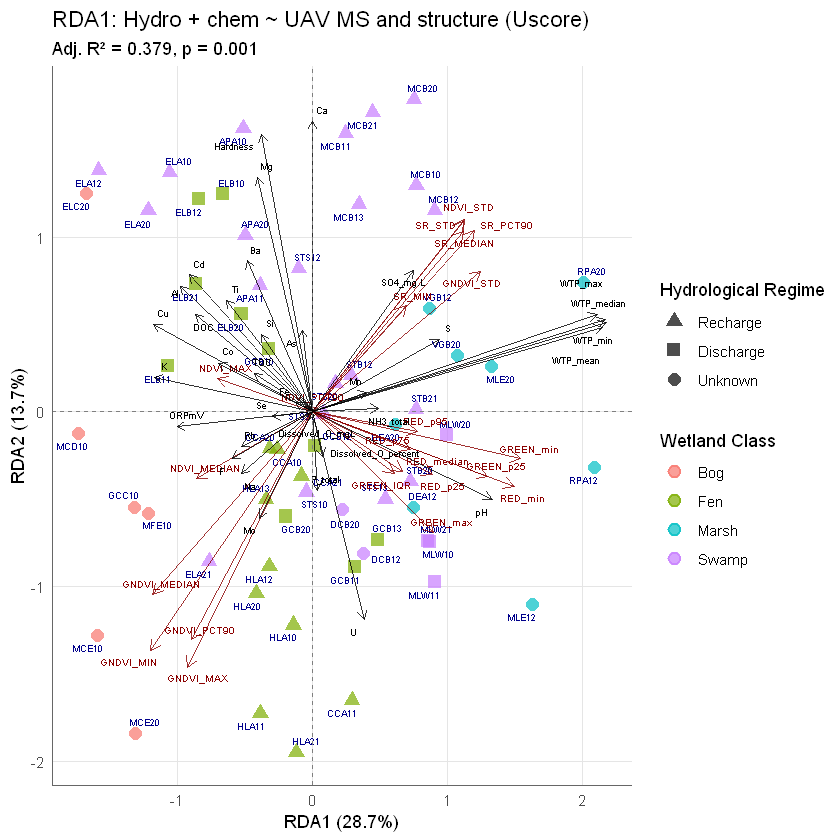

In [208]:
# ============================================================================
# STEP 8: Extract Scores for Plotting
# ============================================================================
# Site scores
site_scores <- as.data.frame(scores(rda_global, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class  # Add wetland class for coloring

# ADD HYDROLOGICAL REGIME INFORMATION
site_scores$Recharge <- df$Recharge
site_scores$Discharge <- df$Discharge
site_scores$unknown_hydro <- df$unknown_hydro

# Create a categorical variable for hydro regime
site_scores$HydroRegime <- case_when(
  site_scores$Recharge == 1 ~ "Recharge",
  site_scores$Discharge == 1 ~ "Discharge",
  site_scores$unknown_hydro == 1 ~ "Unknown",
  TRUE ~ "Unknown"  # Fallback
)

# Convert to factor with specific order
site_scores$HydroRegime <- factor(site_scores$HydroRegime, 
                                   levels = c("Recharge", "Discharge", "Unknown"))

# Predictor arrows (vegetation variables)
arrow_scores <- as.data.frame(scores(rda_global, display = "bp", scaling = 2))
arrow_scores$Variable <- rownames(arrow_scores)

# Response arrows (hydrogeochemistry variables)
response_scores <- as.data.frame(scores(rda_global, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# Get axis labels with variance explained
eig <- summary(rda_global)$concont$importance[2, 1:2]
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

# ============================================================================
# STEP 9: Scale arrows for visibility
# ============================================================================
# Scale vegetation predictors (red arrows)
arrow_scale_veg <- 4
arrow_scores$RDA1_scaled <- arrow_scores$RDA1 * arrow_scale_veg
arrow_scores$RDA2_scaled <- arrow_scores$RDA2 * arrow_scale_veg

# Scale hydrogeochemistry response (black arrows)
arrow_scale_response <- 2
response_scores$RDA1_scaled <- response_scores$RDA1 * arrow_scale_response
response_scores$RDA2_scaled <- response_scores$RDA2 * arrow_scale_response

# ============================================================================
# STEP 10: Triplot with Shape Mapping
# ============================================================================
# Create subtitle with adjusted R² and p-value
subtitle_text <- sprintf("Adj. R² = %.3f, p = %.3f", 
                        r2_global$adj.r.squared, 
                        anova_global$`Pr(>F)`[1])

ggplot() +
  # Sites as points, colored by wetland class, shaped by hydro regime
  geom_point(data = site_scores, 
             aes(x = RDA1, y = RDA2, color = Class, shape = HydroRegime), 
             size = 3, alpha = 0.7, stroke = 1) +
  
  # Define shape mapping: triangle = recharge, square = discharge, circle = unknown
  scale_shape_manual(
    name = "Hydrological Regime",
    values = c("Recharge" = 17,      # filled triangle
               "Discharge" = 15,      # filled square
               "Unknown" = 16),       # filled circle
    labels = c("Recharge", "Discharge", "Unknown")
  ) +
  
  # Site labels
  geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  
  # Vegetation predictor arrows (RED)
  geom_segment(data = arrow_scores,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "darkred", linewidth = 0.2, alpha = 0.8) +
  
  # Vegetation predictor labels
  geom_text_repel(data = arrow_scores,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "darkred", size = 2.2,
                  max.overlaps = 50,
                  segment.color = NA,
                  box.padding = 0.2) +
  
  # Hydrogeochemistry response arrows (BLACK)
  geom_segment(data = response_scores,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.2, "cm")), 
               color = "black", linewidth = 0.2, alpha = 0.8) +
  
  # Hydrogeochemistry response labels
  geom_text_repel(data = response_scores,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "black", size = 2,
                  max.overlaps = 200,
                  segment.color = NA) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title = "RDA1: Hydro + chem ~ UAV MS and structure (Uscore)",
    subtitle = subtitle_text,
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey40", linewidth = 0.3),
    legend.position = "right",
    legend.box = "vertical"  # Stack the two legends vertically
  )

# NEW: Forward selection

In [209]:
set.seed(123)

mod0 <- rda(response ~ 1, predictors, scale = TRUE) # model with intercept only 
mod1 <- rda(response ~ ., predictors, scale = TRUE) # model with all explanatory variables

perm_ctrl <- how(nperm = 999) # permutation settings

# 4. Forward selection using adjusted R2 (Blanchet method)
mod_forward <- ordiR2step(
  object         = mod0,        # start with null
  scope          = mod1,        # full set of predictors
  Pin            = 0.05,        # mod strict alpha
  R2scope        = TRUE,        # do not exceed global adjR2
  permutations   = perm_ctrl,
  R2permutations = 999,
  trace          = TRUE
)

Step: R2.adj= 0 
Call: response ~ 1 
 
                     R2.adjusted
<All variables>     0.3791034530
+ IQR_veg_height    0.0374005225
+ P95_veg_height    0.0360999140
+ P75_veg_height    0.0353424061
+ stem_density      0.0348248485
+ CanopyCover1m     0.0316605530
+ median_veg_height 0.0306165611
+ stddev_veg_height 0.0286311809
+ CanopyCover2m     0.0285950033
+ P25_veg_height    0.0267035310
+ GNDVI_MIN         0.0265396817
+ SR_PCT90          0.0217704155
+ GNDVI_PCT90       0.0217062643
+ NIR_max           0.0212631870
+ GNDVI_MAX         0.0208563566
+ GNDVI_MEDIAN      0.0203261411
+ SR_STD            0.0200287680
+ REDEDGE_stdev     0.0198674138
+ GNDVI_STD         0.0196132844
+ SR_MEDIAN         0.0194831852
+ NDVI_STD          0.0192188503
+ NIR_iqr           0.0185740336
+ REDEDGE_IQR       0.0183686769
+ NIR_min           0.0178826672
+ REDEDGE_max       0.0175067531
+ GREEN_min         0.0174203557
+ REDEDGE_p95       0.0170782637
+ max_veg_height    0.0161867558
+ RE

In [210]:
RsquareAdj(mod_forward)      # final adjusted R²
anova(mod_forward)           # overall significance
anova(mod_forward, by = "axis")  # axis-wise tests
anova(mod_forward, by = "term")  # each selected predictor


$r.squared
[1] 0.5620435

$adj.r.squared
[1] 0.3743478

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,18,19.10948,2.99444,0.001
Residual,42,14.89052,NA,NA


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,5.7645610,16.25944069,0.001
RDA2,1,2.8036506,7.90793791,0.001
RDA3,1,2.0748408,5.85226712,0.001
RDA4,1,1.6887662,4.76331046,0.006
RDA5,1,1.5200913,4.28754828,0.015
RDA6,1,1.2046658,3.39786364,0.093
RDA7,1,0.8356362,2.35698394,0.816
RDA8,1,0.6988441,1.97115004,0.958
RDA9,1,0.4972946,1.40266227,1.000


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
IQR_veg_height,1,1.8170908,5.125261,0.001
NIR_max,1,1.4837613,4.185076,0.001
NIR_min,1,1.8020715,5.082898,0.001
GNDVI_PCT90,1,1.1611921,3.275242,0.001
SR_PCT90,1,1.1859895,3.345186,0.001
NIR_75,1,1.0704147,3.019197,0.001
REDEDGE_median,1,1.3189286,3.720152,0.001
RED_p75,1,0.9623957,2.714520,0.001
P75_veg_height,1,1.1811284,3.331474,0.001


# Re-Run RDA with forward selected vars

In [211]:
# ==============================
# STEP 2: Final RDA model
# ==============================

# 1) Extract selected predictors from the full predictor matrix
selected_vars <- attr(terms(mod_forward), "term.labels")
selected_vars

predictors_sel <- predictors[, selected_vars, drop = FALSE]

# 2) Refit RDA using only selected predictors (optional but clear)
#rda_final <- rda(response ~ ., data = predictors_sel, scale = TRUE)

# If you prefer, you can just do:
rda_final <- mod_forward
summary(rda_final)

# ==============================
# STEP 3: Model statistics
# ==============================

# Adjusted R²
r2_final <- RsquareAdj(rda_final)
r2_final  # $r.squared and $adj.r.squared

# Overall model significance
anova_final <- anova.cca(rda_final, permutations = 999)
anova_final

# Test each axis
anova_axes <- anova.cca(rda_final, by = "axis", permutations = 999)
anova_axes

# Test each predictor variable
anova_terms <- anova.cca(rda_final, by = "term", permutations = 999)
anova_terms


[1] "IQR_veg_height" "NIR_max"        "NIR_min"        "GNDVI_PCT90"   
 [5] "SR_PCT90"       "NIR_75"         "REDEDGE_median" "RED_p75"       
 [9] "P75_veg_height" "CanopyCover1m"  "GREEN_min"      "RED_p95"       
[13] "GNDVI_STD"      "NIR_median"     "REDEDGE_p25"    "CanopyCover2m" 
[17] "stem_density"   "SR_MIN"


Call:
rda(formula = response ~ IQR_veg_height + NIR_max + NIR_min +      GNDVI_PCT90 + SR_PCT90 + NIR_75 + REDEDGE_median + RED_p75 +      P75_veg_height + CanopyCover1m + GREEN_min + RED_p95 + GNDVI_STD +      NIR_median + REDEDGE_p25 + CanopyCover2m + stem_density +      SR_MIN, data = predictors, scale = TRUE) 

Partitioning of correlations:
              Inertia Proportion
Total           34.00      1.000
Constrained     19.11      0.562
Unconstrained   14.89      0.438

Eigenvalues, and their contribution to the correlations 

Importance of components:
                        RDA1    RDA2    RDA3    RDA4    RDA5    RDA6    RDA7
Eigenvalue            5.7646 2.80365 2.07484 1.68877 1.52009 1.20467 0.83564
Proportion Explained  0.1695 0.08246 0.06102 0.04967 0.04471 0.03543 0.02458
Cumulative Proportion 0.1695 0.25201 0.31303 0.36270 0.40741 0.44284 0.46742
                         RDA8    RDA9   RDA10   RDA11    RDA12    RDA13
Eigenvalue            0.69884 0.49729 0.43832 0.34968 0

$r.squared
[1] 0.5620435

$adj.r.squared
[1] 0.3743478

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,18,19.10948,2.99444,0.001
Residual,42,14.89052,NA,NA


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,5.7645610,16.25944069,0.001
RDA2,1,2.8036506,7.90793791,0.001
RDA3,1,2.0748408,5.85226712,0.001
RDA4,1,1.6887662,4.76331046,0.004
RDA5,1,1.5200913,4.28754828,0.012
RDA6,1,1.2046658,3.39786364,0.098
RDA7,1,0.8356362,2.35698394,0.816
RDA8,1,0.6988441,1.97115004,0.960
RDA9,1,0.4972946,1.40266227,1.000


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
IQR_veg_height,1,1.8170908,5.125261,0.001
NIR_max,1,1.4837613,4.185076,0.001
NIR_min,1,1.8020715,5.082898,0.001
GNDVI_PCT90,1,1.1611921,3.275242,0.001
SR_PCT90,1,1.1859895,3.345186,0.001
NIR_75,1,1.0704147,3.019197,0.002
REDEDGE_median,1,1.3189286,3.720152,0.001
RED_p75,1,0.9623957,2.714520,0.002
P75_veg_height,1,1.1811284,3.331474,0.001


## Plot reduced var RDA

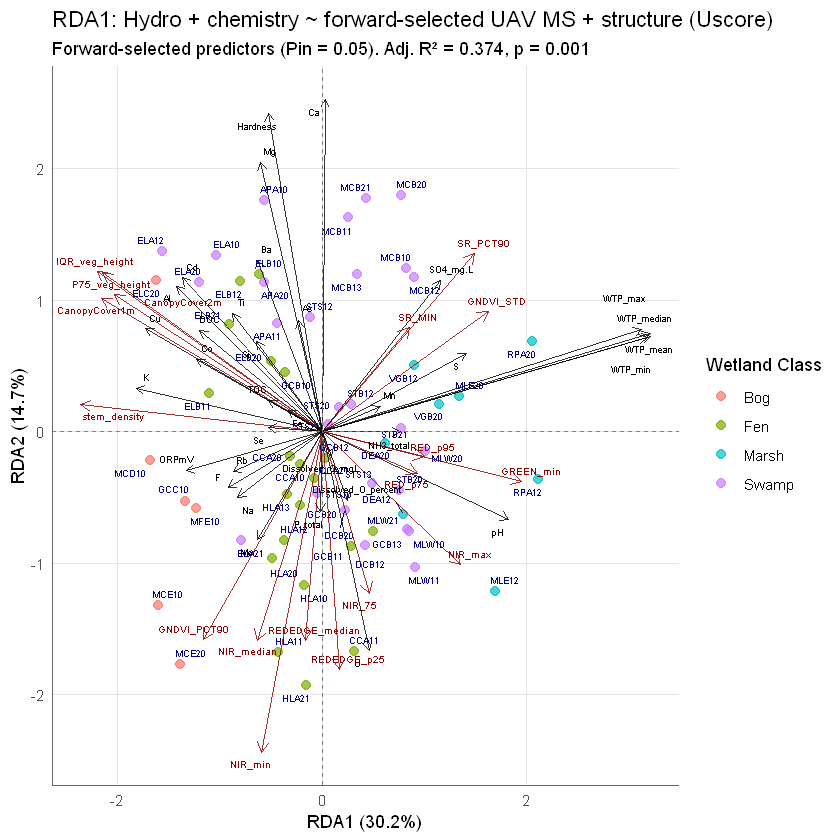

In [212]:
# ==============================
# STEP 4: Extract scores
# ==============================

# Site scores
site_scores <- as.data.frame(scores(rda_final, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class  <- df$Class  # wetland class for coloring

# Predictor arrows (vegetation variables = constrained predictors)
arrow_scores <- as.data.frame(scores(rda_final, display = "bp", scaling = 2))
arrow_scores$Variable <- rownames(arrow_scores)

# Response arrows (hydro + chem = 'species' in vegan's language)
response_scores <- as.data.frame(scores(rda_final, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# ==============================
# Axis labels with variance explained
# ==============================

eig <- summary(rda_final)$concont$importance[2, 1:2]  # proportion of constrained variance for RDA1 & RDA2
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

# ==============================
# Scale arrows for visibility
# ==============================

# Vegetation predictors (red arrows)
arrow_scale_veg <- 5
arrow_scores$RDA1_scaled <- arrow_scores$RDA1 * arrow_scale_veg
arrow_scores$RDA2_scaled <- arrow_scores$RDA2 * arrow_scale_veg

# Hydro + chem responses (black arrows)
arrow_scale_response <- 3
response_scores$RDA1_scaled <- response_scores$RDA1 * arrow_scale_response
response_scores$RDA2_scaled <- response_scores$RDA2 * arrow_scale_response

# ==============================
# Subtitle: adjusted R² + model p-value
# ==============================

subtitle_text <- sprintf(
  "Forward-selected predictors (Pin = 0.05). Adj. R² = %.3f, p = %.3f",
  r2_final$adj.r.squared,
  anova_final$`Pr(>F)`[1]
)

# ==============================
# Triplot (same style as before)
# ==============================

ggplot() +
  # Sites as points, coloured by wetland class
  geom_point(
    data = site_scores,
    aes(x = RDA1, y = RDA2, color = Class),
    size = 2.5, alpha = 0.7
  ) +
  
  # Site labels
  geom_text_repel(
    data = site_scores,
    aes(x = RDA1, y = RDA2, label = SiteID),
    color = "darkblue",
    size = 2,
    max.overlaps = 10
  ) +
  
  # Vegetation predictor arrows (RED)
  geom_segment(
    data = arrow_scores,
    aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
    arrow = arrow(length = unit(0.25, "cm")),
    color = "darkred",
    linewidth = 0.2,
    alpha = 0.8
  ) +
  
  # Vegetation predictor labels
  geom_text_repel(
    data = arrow_scores,
    aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
    color = "darkred",
    size = 2.2,
    max.overlaps = 50,
    segment.color = NA,
    box.padding = 0.2
  ) +
  
  # Hydrogeochemistry response arrows (BLACK)
  geom_segment(
    data = response_scores,
    aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
    arrow = arrow(length = unit(0.2, "cm")),
    color = "black",
    linewidth = 0.2,
    alpha = 0.8
  ) +
  
  # Hydrogeochemistry response labels
  geom_text_repel(
    data = response_scores,
    aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
    color = "black",
    size = 2,
    max.overlaps = 200,
    segment.color = NA
  ) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title    = "RDA1: Hydro + chemistry ~ forward-selected UAV MS + structure (Uscore)",
    subtitle = subtitle_text,
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line        = element_line(color = "grey40", linewidth = 0.3),
    legend.position  = "right"
  )


In [ ]:
# Predictor (constraining) scores
pred_scores <- as.data.frame(scores(rda_final, display = "bp", scaling = 2))
pred_scores$Variable <- rownames(pred_scores)

# Top N to show
N <- 10

# Top predictors for RDA1 (by absolute loading)
top_pred_RDA1 <- pred_scores[order(-abs(pred_scores$RDA1)), c("Variable", "RDA1")][1:N, ]
top_pred_RDA1

# Top predictors for RDA2
top_pred_RDA2 <- pred_scores[order(-abs(pred_scores$RDA2)), c("Variable", "RDA2")][1:N, ]
top_pred_RDA2


In [ ]:
# Response scores (hydro + chemistry)
resp_scores <- as.data.frame(scores(rda_final, display = "species", scaling = 2))
resp_scores$Variable <- rownames(resp_scores)

N <- 8  # top 8

# Top responses for RDA1
top_resp_RDA1 <- resp_scores[order(-abs(resp_scores$RDA1)), c("Variable", "RDA1")][1:N, ]
top_resp_RDA1

# Top responses for RDA2
top_resp_RDA2 <- resp_scores[order(-abs(resp_scores$RDA2)), c("Variable", "RDA2")][1:N, ]
top_resp_RDA2


## Kaiser–Guttman criterion 

In [168]:
# Show me all the residual axes that have eigenvalues bigger than the average residual eigenvalue
# leftover gradients in the data that are not explained by the predictors
rda_final$CA$eig[rda_final$CA$eig > mean(rda_final$CA$eig)]
rda_global$CA$eig[rda_global$CA$eig > mean(rda_global$CA$eig)]


PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8 
4.8922958 2.3503024 1.8617161 1.5951720 1.4459091 1.0805722 0.9064958 0.6394303

PC1       PC2       PC3       PC4       PC5       PC6       PC7 
4.1580901 1.9374625 1.1565637 0.8179493 0.5603029 0.5048845 0.4090855

# PCA for Field Veg and Hydrochem

[1] "SiteID"                "Class"                 "class_num"            
  [4] "Date.Sampled"          "Time.Sampled"          "NDVI_amp_harmonic"    
  [7] "NDVI_phase_harmonic"   "TCW_p10"               "TCW_p40"              
 [10] "TCW_p80"               "TCW_p90"               "SWI_median"           
 [13] "SWI_stdev"             "SWI_p90"               "log_DDG_mean"         
 [16] "log_DDG_median"        "log_DDS_min"           "log_DDS_max"          
 [19] "log_DDS_stdev"         "log_MCA_stdev"         "log_MCA_p90"          
 [22] "log_VDCN_median"       "log_VDCN_mean"         "log_VDCN_min"         
 [25] "log_VDCN_max"          "log_VDCN_stdev"        "HOFD_median"          
 [28] "HOFD_mean"             "HOFD_min"              "HOFD_max"             
 [31] "HOFD_stdev"            "HOFD_p90"              "VOFD_mean"            
 [34] "VOFD_min"              "VOFD_max"              "VOFD_stdev"           
 [37] "VOFD_p90"              "Geom_mode_9"           "Geom_mode_10"         
 [40] "NDVI_MAX"              "NDVI_RANGE"            "NDVI_MEAN"            
 [43] "NDVI_STD"              "NDVI_MEDIAN"           "NDVI_PCT90"           
 [46] "GNDVI_MIN"             "GNDVI_MAX"             "GNDVI_RANGE"          
 [49] "GNDVI_MEAN"            "GNDVI_STD"             "GNDVI_MEDIAN"         
 [52] "GNDVI_PCT90"           "SR_MIN"                "SR_MAX"               
 [55] "SR_RANGE"              "SR_MEAN"               "SR_STD"               
 [58] "SR_MEDIAN"             "SR_PCT90"              "RED_median"           
 [61] "RED_min"               "RED_p25"               "RED_p75"              
 [64] "RED_p95"               "GREEN_max"             "GREEN_min"            
 [67] "GREEN_p25"             "GREEN_IQR"             "REDEDGE_median"       
 [70] "REDEDGE_max"           "REDEDGE_min"           "REDEDGE_p25"          
 [73] "REDEDGE_p95"           "REDEDGE_IQR"           "REDEDGE_stdev"        
 [76] "NIR_mean"              "NIR_median"            "NIR_max"              
 [79] "NIR_min"               "NIR_p25"               "NIR_75"               
 [82] "NIR_iqr"               "average_veg_height"    "median_veg_height"    
 [85] "max_veg_height"        "min_veg_height"        "stddev_veg_height"    
 [88] "P95_veg_height"        "P75_veg_height"        "P25_veg_height"       
 [91] "IQR_veg_height"        "CanopyCover1m"         "CanopyCover2m"        
 [94] "stem_density"          "WTP_max"               "WTP_min"              
 [97] "WTP_median"            "WTP_mean"              "WTP_stdev"            
[100] "WTP_range"             "Recharge"              "Discharge"            
[103] "unknown_hydro"         "VHG_average"           "VHG_median"           
[106] "VHG_max"               "VHG_min"               "VHG_stdev"            
[109] "VHG_range"             "small_tree"            "shrub"                
[112] "graminoid"             "moss"                  "lichen"               
[115] "dom_tall_tree_none"    "dom_small_tree_will"   "dom_small_tree_spruce"
[118] "dom_small_tree_none"   "dom_graminoid_grass"   "dom_moss_sphag"       
[121] "dom_moss_other_bryo"   "equisetum_dom"         "Al"                   
[124] "As"                    "Ba"                    "Cd"                   
[127] "Ca"                    "Co"                    "Cu"                   
[130] "F"                     "Fe"                    "Mg"                   
[133] "Mn"                    "Mo"                    "K"                    
[136] "Rb"                    "Se"                    "Si"                   
[139] "Na"                    "S"                     "Ti"                   
[142] "U"                     "DOC"                   "TOC"                  
[145] "P_total"               "NH3_total"             "Hardness"             
[148] "SO4_mg.L"              "Dissolved_O_percent"   "Dissolved_O_mgL"      
[151] "pH"                    "ORPmV"                 "SpC"


PC1 explains: 16.98 % of variance
PC2 explains: 11.33 % of variance
PC1+PC2 together explain: 28.31 % of variance
[1] "Top 10 variables on PC1:"
             Variable        PC1 contrib_PC1
WTP_mean     WTP_mean  1.0240259   1.0240259
WTP_median WTP_median  1.0214487   1.0214487
WTP_min       WTP_min  1.0116530   1.0116530
WTP_max       WTP_max  0.9917525   0.9917525
pH                 pH  0.6428546   0.6428546
K                   K -0.6070645   0.6070645
Cu                 Cu -0.6031610   0.6031610
S                   S  0.5490243   0.5490243
moss             moss -0.5437916   0.5437916
Al                 Al -0.5342428   0.5342428
[1] "\nTop 10 variables on PC2:"
                               Variable        PC2 contrib_PC2
Hardness                       Hardness -0.8522469   0.8522469
Mg                                   Mg -0.8519849   0.8519849
Ca                                   Ca -0.8471543   0.8471543
shrub                             shrub  0.6585383   0.6585383
graminoid  

Warning message:
"ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


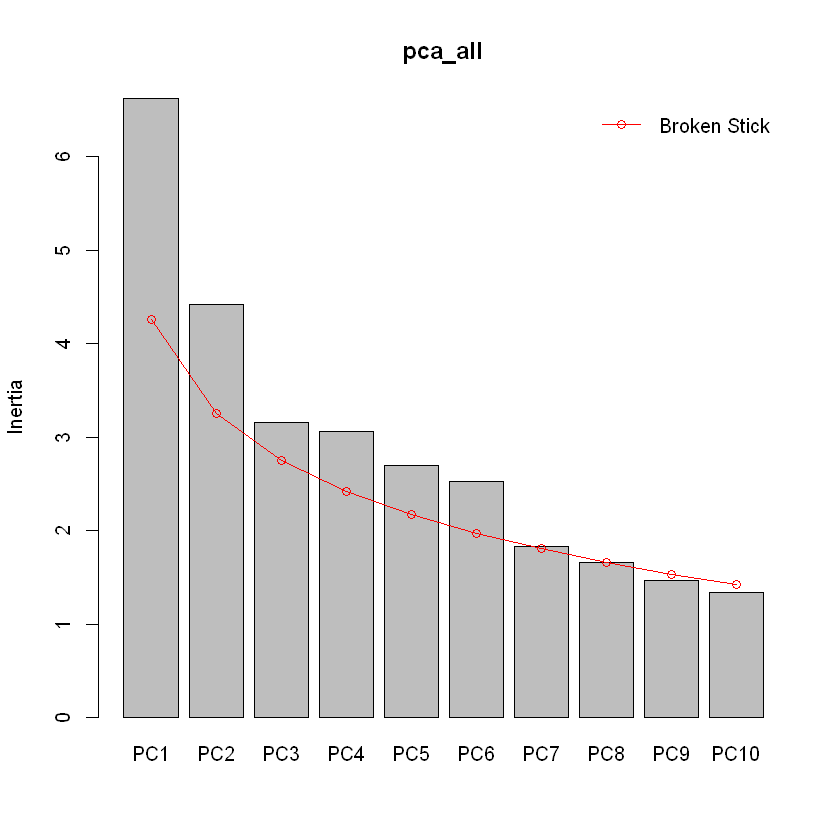

Warning message:
"ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


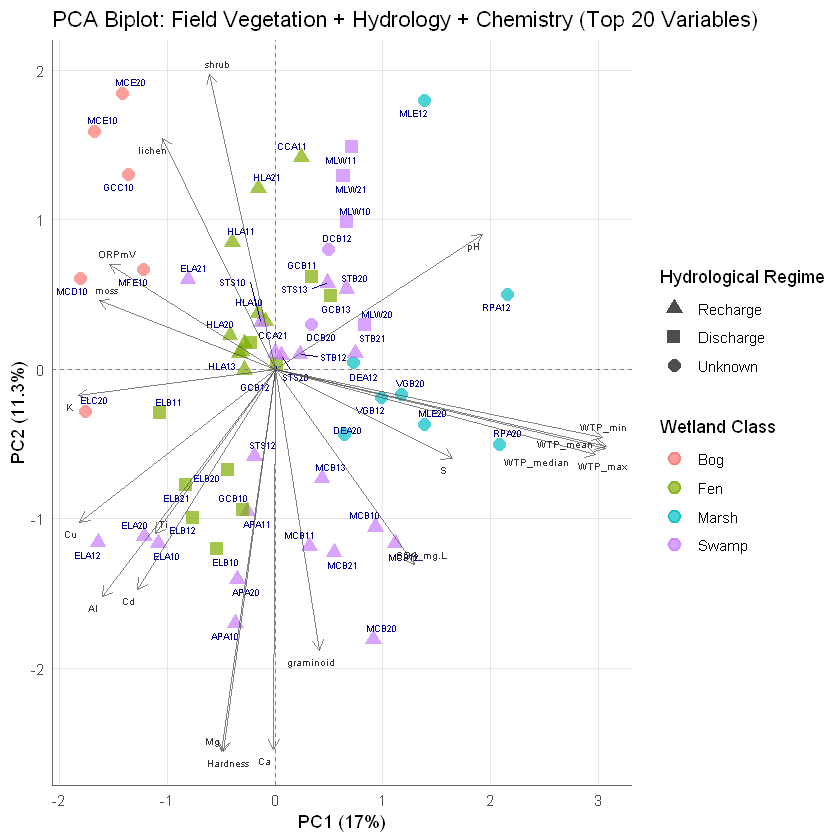

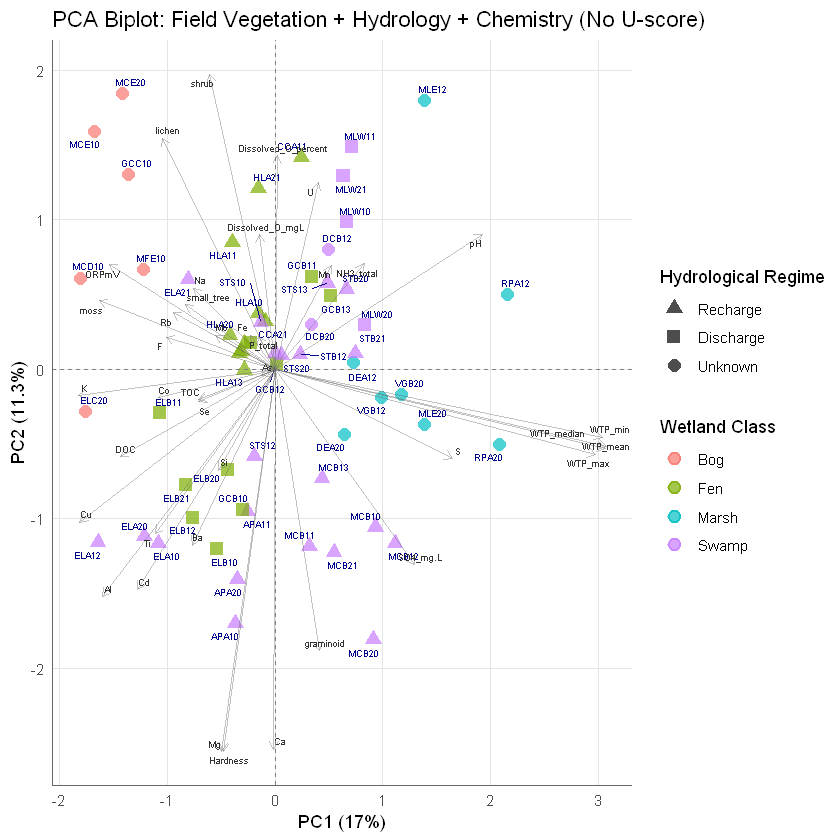

In [214]:
# ============================================================================
# PCA: Field Vegetation + Hydrology + Chemistry
# ============================================================================

df <- read.csv("C:/Users/leila/Dropbox/MayoWetlands/wetland_alldata_2025_uscore_reduced.csv") #nolint 
# Remove Upland class
df <- df[df$Class != "UL", ]

# remove Hornpeak sites because we are using WTP data now
hornpeak <- c("HPA", "HPB", "HPC", "HPD", "HPE")
df <- df[!df$SiteID %in% hornpeak, ]

names(df)

# IMPORTANT: Save hydro regime columns BEFORE removing them
df$Recharge_regime <- df$Recharge
df$Discharge_regime <- df$Discharge
df$unknown_hydro_regime <- df$unknown_hydro

# Remove VHG variables and hydro regime indicators from analysis
hydro_cols <- hydro_cols[!grepl("VHG", hydro_cols)]
df <- df %>%
  select(-Discharge, -unknown_hydro, -Recharge)

# Combine vegetation + hydrology + chemistry into one PCA matrix
pca_vars <- df[, c(field_cols, hydro_cols, chem_cols)]

# Scale everything before PCA
pca_scaled <- scale(pca_vars)

# Run PCA (vegan style)
pca_all <- rda(pca_scaled) 

# ============================================================================
# STEP 1: Check variance explained and scree plot
# ============================================================================
screeplot(pca_all, bstick = TRUE)

# Get variance explained by each PC axis
pca_summary <- summary(pca_all)
eigenvalues <- pca_summary$cont$importance

# Print variance explained
cat("\nPC1 explains:", round(eigenvalues[2,1] * 100, 2), "% of variance\n")
cat("PC2 explains:", round(eigenvalues[2,2] * 100, 2), "% of variance\n")
cat("PC1+PC2 together explain:", round(eigenvalues[3,2] * 100, 2), "% of variance\n")

# ============================================================================
# STEP 2: Extract scores for plotting
# ============================================================================
# Site scores
site_scores <- as.data.frame(scores(pca_all, display = "sites", choices = 1:2))
site_scores$SiteID <- df$SiteID
site_scores$Class <- df$Class

# ADD HYDROLOGICAL REGIME INFORMATION
site_scores$Recharge <- df$Recharge_regime
site_scores$Discharge <- df$Discharge_regime
site_scores$unknown_hydro <- df$unknown_hydro_regime

# Create a categorical variable for hydro regime
site_scores$HydroRegime <- case_when(
  site_scores$Recharge == 1 ~ "Recharge",
  site_scores$Discharge == 1 ~ "Discharge",
  site_scores$unknown_hydro == 1 ~ "Unknown",
  TRUE ~ "Unknown"  # Fallback
)

# Convert to factor with specific order
site_scores$HydroRegime <- factor(site_scores$HydroRegime, 
                                   levels = c("Recharge", "Discharge", "Unknown"))

# Variable loadings
var_scores <- as.data.frame(scores(pca_all, display = "species", choices = 1:2))
var_scores$Variable <- rownames(var_scores)

# Get axis labels with variance explained
xlab_pct <- paste0("PC1 (", round(eigenvalues[2,1] * 100, 1), "%)")
ylab_pct <- paste0("PC2 (", round(eigenvalues[2,2] * 100, 1), "%)")

# ============================================================================
# STEP 3: Identify top contributing variables
# ============================================================================
# Calculate contribution to PC1 and PC2
var_scores$contrib_PC1 <- abs(var_scores$PC1)
var_scores$contrib_PC2 <- abs(var_scores$PC2)
var_scores$total_contrib <- sqrt(var_scores$PC1^2 + var_scores$PC2^2)

# Get top 10 for each axis
top_PC1 <- var_scores %>%
  arrange(desc(contrib_PC1)) %>%
  slice_head(n = 10) %>%
  select(Variable, PC1, contrib_PC1)

top_PC2 <- var_scores %>%
  arrange(desc(contrib_PC2)) %>%
  slice_head(n = 10) %>%
  select(Variable, PC2, contrib_PC2)

print("Top 10 variables on PC1:")
print(top_PC1)

print("\nTop 10 variables on PC2:")
print(top_PC2)

# Select top 20 overall contributors for plotting
top_vars <- var_scores %>%
  arrange(desc(total_contrib)) %>%
  slice_head(n = 20) %>%
  pull(Variable)

var_scores_top <- var_scores %>%
  filter(Variable %in% top_vars)

# ============================================================================
# STEP 4: Scale arrows for visibility
# ============================================================================
arrow_scale <- 3
var_scores_top$PC1_scaled <- var_scores_top$PC1 * arrow_scale
var_scores_top$PC2_scaled <- var_scores_top$PC2 * arrow_scale

# ============================================================================
# STEP 5: Create PCA biplot with hydro regime shapes
# ============================================================================
ggplot() +
  # Sites as points, colored by wetland class, shaped by hydro regime
  geom_point(data = site_scores, 
             aes(x = PC1, y = PC2, color = Class, shape = HydroRegime), 
             size = 3, alpha = 0.7, stroke = 1) +
  
  # Define shape mapping: triangle = recharge, square = discharge, circle = unknown
  scale_shape_manual(
    name = "Hydrological Regime",
    values = c("Recharge" = 17,      # filled triangle
               "Discharge" = 15,      # filled square
               "Unknown" = 16),       # filled circle
    labels = c("Recharge", "Discharge", "Unknown")
  ) +
  
  # Site labels
  geom_text_repel(data = site_scores, 
                  aes(x = PC1, y = PC2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  
  # Variable arrows (top contributors)
  geom_segment(data = var_scores_top,
               aes(x = 0, y = 0, xend = PC1_scaled, yend = PC2_scaled),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "grey30", linewidth = 0.2, alpha = 0.7) +
  
  # Variable labels
  geom_text_repel(data = var_scores_top,
                  aes(x = PC1_scaled, y = PC2_scaled, label = Variable),
                  color = "grey20", size = 2.2,
                  max.overlaps = 50,
                  segment.color = NA,
                  box.padding = 0.2) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title = "PCA Biplot: Field Vegetation + Hydrology + Chemistry (Top 20 Variables)",
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey40", linewidth = 0.3),
    legend.position = "right",
    legend.box = "vertical"  # Stack the two legends vertically
  )

# ============================================================================
# OPTIONAL: Biplot with ALL variables (with hydro regime shapes)
# ============================================================================
# Scale all variables
var_scores_all <- var_scores
var_scores_all$PC1_scaled <- var_scores_all$PC1 * arrow_scale
var_scores_all$PC2_scaled <- var_scores_all$PC2 * arrow_scale

ggplot() +
  # Sites with both class color and hydro regime shape
  geom_point(data = site_scores, 
             aes(x = PC1, y = PC2, color = Class, shape = HydroRegime), 
             size = 3, alpha = 0.7, stroke = 1) +
  
  scale_shape_manual(
    name = "Hydrological Regime",
    values = c("Recharge" = 17, "Discharge" = 15, "Unknown" = 16),
    labels = c("Recharge", "Discharge", "Unknown")
  ) +
  
  geom_text_repel(data = site_scores, 
                  aes(x = PC1, y = PC2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  
  geom_segment(data = var_scores_all,
               aes(x = 0, y = 0, xend = PC1_scaled, yend = PC2_scaled),
               arrow = arrow(length = unit(0.2, "cm")), 
               color = "grey40", linewidth = 0.15, alpha = 0.4) +
  
  geom_text_repel(data = var_scores_all,
                  aes(x = PC1_scaled, y = PC2_scaled, label = Variable),
                  color = "grey20", size = 1.8,
                  max.overlaps = 200,
                  segment.color = NA,
                  box.padding = 0.1) +
  
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title = "PCA Biplot: Field Vegetation + Hydrology + Chemistry (No U-score)",
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey40", linewidth = 0.3),
    legend.position = "right",
    legend.box = "vertical"
  )